# 5. Masking & Filtering: Selection by Value

The [sub-region pages](03_hydro_Get_Subregions.md) select by **place** — a sphere,
a cylinder, a slab. This page selects by **state**: temperature, density, age,
speed, or any quantity Mera can derive. The two are independent, they compose in
either order, and together they cover most of what "give me *this* gas" means.

Two verbs do the work, and the only difference is what they hand back:

| | returns | use it when |
|:--|:--|:--|
| `filterdata(obj, condition)` | a **new object** of the same type | you want to carry on working — project it, cut it, weigh it |
| `getmask(obj, condition)` | a **`Vector{Bool}`** over the rows | you want to pass `mask=` to a Mera function and keep the original object |

Everything else on this page is about writing the *condition*.

**Reading convention.** Longer code cells are cut in two by a banner line:

```
# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
```

Everything above the banner is the Mera part; everything below is Makie
decoration.

**On this page**

1. selection by state
2. a condition is a quantity, a threshold and a unit
3. combining conditions
4. two shapes: an object or a mask
5. masks inside Mera's own functions
6. seeing what a filter keeps
7. place × value
8. adding a column of your own
9. reference: the raw table path
10. practical guidance


## 1. Selection by State

The same galaxy as the sub-region pages, at `lmax=8` so the page stays quick.
All three data types are loaded, because filtering is not a hydro-only idea —
particles filter on age, clumps on their catalogue properties.


In [1]:
using Mera

path = "/Volumes/FASTStorage/Simulations/Mera-Tests/RAMSES/manu_sim_sf_L14"
info = getinfo(400, path, verbose=false)

gas       = gethydro(info, lmax=8, smallr=1e-5, verbose=false, show_progress=false)
particles = getparticles(info, verbose=false, show_progress=false)
clumps    = getclumps(info, verbose=false)

println("gas cells      : ", length(gas.data))
println("star particles : ", length(particles.data))
println("clumps         : ", length(clumps.data))



*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0



gas cells      : 849332


star particles : 508939
clumps         : 644


In [2]:
# the two verbs, on the same condition
hot  = filterdata(gas, Above(:T, 1e6, unit=:K), verbose=false)   # -> a HydroDataType
mask = getmask(gas,    Above(:T, 1e6, unit=:K))                   # -> a Vector{Bool}

println("filterdata → ", typeof(hot).name.name, ", ", length(hot.data), " cells")
println("getmask    → ", typeof(mask), ", ", count(mask), " true of ", length(mask))
println()
println("mass of hot gas, via the object : ", round(msum(hot, :Msol), sigdigits=6), " Msol")
println("            ... via the mask    : ", round(msum(gas, :Msol, mask=mask), sigdigits=6), " Msol")
println("identical                       : ", msum(hot, :Msol) == msum(gas, :Msol, mask=mask))


filterdata → HydroDataType

, 489608 cells
getmask    → BitVector

, 489608 true of 849332

mass of hot gas, via the object : 2.14499e9

 Msol
            ... via the mask    : 2.14499e9

 Msol
identical                       : true

Same selection, same answer, two shapes. Which one you want depends on what comes
next — §4 makes that concrete.


## 2. A Condition Is a Quantity, a Threshold and a Unit

`Above`, `Below`, `InRange` and `Equals` take a **quantity name**, a value, and
the unit that value is in. The quantity may be a stored column (`:rho`) or
anything `getvar` can *derive* — temperature, sound speed, Mach number, a
cylindrical radius. That is the whole point: you write the physics, not the code
that reconstructs it.


In [3]:
conds = [
    ("Above(:rho, 1, :nH)          ", Above(:rho, 1, unit=:nH)),            # stored column
    ("Below(:T, 2e4, :K)           ", Below(:T, 2e4, unit=:K)),             # derived: temperature
    ("Above(:cs, 20, :km_s)        ", Above(:cs, 20, unit=:km_s)),          # derived: sound speed
    ("Above(:mach, 1)              ", Above(:mach, 1)),                     # derived, dimensionless
    ("InRange(:r_cylinder, 0,10,:kpc)", InRange(:r_cylinder, 0, 10, unit=:kpc)),  # derived geometry
    ("Equals(:level, gas.lmax)     ", Equals(:level, gas.lmax)),            # discrete
]
m_all = msum(gas, :Msol)
println(rpad("condition", 34), rpad("cells", 10), "mass share")
println("-"^60)
for (name, c) in conds
    s = filterdata(gas, c, verbose=false)
    println(rpad(name, 34), rpad(length(s.data), 10),
            round(100 * msum(s, :Msol) / m_all, digits=1), " %")
end


condition                         cells     

mass share
------------------------------------------------------------
Above(:rho, 1, :nH)               10126     79.8 %
Below(:T, 2e4, :K)                33569     37.0 %
Above(:cs, 20, :km_s)             652583    

44.6 %
Above(:mach, 1)                   

520858    94.5 %
[Mera] Hint: getvar(:r_cylinder) has no `center` — it is measured about the box CORNER.


             Pass center=[:bc] for the box centre, or center=[x, y, z] with center_unit.
             This is a different argument from the `center` that places a region; give it
             the same origin. Absolute positions :x/:y/:z are unaffected.
             (shown once per session; verbose(false) silences Mera's messages)
InRange(:r_cylinder, 0,10,:kpc)   8896      

0.1 %
Equals(:level, gas.lmax)          501568    92.6 %


Note `:r_cylinder` in that list. A *geometric* quantity used as a value
condition selects a cylinder — but by testing each cell's centre, with no
boundary treatment. When the geometry is what you care about, use a region
instead (§7); the exactness is worth it.

Two further selectors are worth knowing:

- `Satisfies(:quantity, f)` — an arbitrary predicate, when a threshold is not enough.
- `IsFinite(:quantity)` — drops `NaN`/`Inf` before a statistic. Data hygiene, and
  cheap insurance.


## 3. Combining Conditions

`&`, `|` and `!` compose conditions into one condition. Passing several
conditions to `filterdata` ANDs them, which reads better for the common case.


In [4]:
cold_dense = filterdata(gas, Above(:rho, 1, unit=:nH) & Below(:T, 1e5, unit=:K), verbose=false)
either     = filterdata(gas, Above(:T, 1e6, unit=:K) | Above(:rho, 10, unit=:nH), verbose=false)
not_cold   = filterdata(gas, !Below(:T, 2e4, unit=:K), verbose=false)
# several arguments = AND, in a form that reads like a sentence
disc_cold  = filterdata(gas, InRange(:r_cylinder, 0, 15, unit=:kpc),
                             Below(:T, 2e4, unit=:K), verbose=false)

for (n, o) in (("rho > 1 nH  AND  T < 1e5 K", cold_dense),
               ("T > 1e6 K   OR   rho > 10 nH", either),
               ("NOT (T < 2e4 K)", not_cold),
               ("r < 15 kpc  AND  T < 2e4 K", disc_cold))
    println(rpad(n, 30), rpad(length(o.data), 9), round(msum(o, :Msol), sigdigits=5), " Msol")
end

# a condition and its complement partition the object exactly
cold = filterdata(gas, Below(:T, 2e4, unit=:K), verbose=false)
println()
println("cold + not-cold cells : ", length(cold.data) + length(not_cold.data),
        "   of ", length(gas.data))
println("cold + not-cold mass  : ", round(msum(cold, :Msol) + msum(not_cold, :Msol), sigdigits=10))
println("whole box mass        : ", round(m_all, sigdigits=10))


rho > 1 nH  AND  T < 1e5 K    10080    

1.6812e10 Msol
T > 1e6 K   OR   rho > 10 nH  490701   2.1381e10 Msol
NOT (T < 2e4 K)               815763   1.9503e10 Msol
r < 15 kpc  AND  T < 2e4 K    516      2.1893e6 Msol

cold + not-cold cells : 849332   of 849332
cold + not-cold mass  : 3.096875415e10
whole box mass        : 3.096875415e10


The partition is exact because `!` is a strict negation of the same test — no
cell is counted twice and none is dropped. That check costs one line and catches
a mis-specified threshold immediately.

**Adaptive and discrete selectors.** Sometimes the threshold should come from the
data rather than from you:


In [5]:
dense10 = filterdata(gas, AbovePercentile(:rho, 90), verbose=false)   # densest 10 % of cells
faint   = filterdata(gas, BelowPercentile(:rho, 10), verbose=false)   # the most diffuse 10 %
core    = filterdata(gas, Equals(:level, gas.lmax) &
                          AbovePercentile(:rho, 99), verbose=false)   # finest AND densest

println("densest 10 % of cells : ", rpad(length(dense10.data), 9),
        round(100*msum(dense10, :Msol)/m_all, digits=1), " % of the mass")
println("faintest 10 %         : ", rpad(length(faint.data), 9),
        round(100*msum(faint, :Msol)/m_all, digits=3), " %")
println("finest level & top 1 %: ", rpad(length(core.data), 9),
        round(100*msum(core, :Msol)/m_all, digits=1), " %")


densest 10 % of cells : 84934    

91.1 % of the mass
faintest 10 %         : 0        0.0 %
finest level & top 1 %: 8494     78.6 %


`AbovePercentile(:rho, 90)` is *the densest tenth of the cells*, whatever the
density scale of this simulation happens to be — the right tool when you have not
looked at the numbers yet, or when the same script must run on several outputs.


## 4. Two Shapes: an Object or a Mask

Both verbs select the same rows. The choice is about what you do next.

**`filterdata` returns an object**, so it chains: project it, cut a region out of
it, filter it again, weigh it. Use it when the selection *is* the thing you are
studying.

**`getmask` returns a `Vector{Bool}`** aligned with the original rows. Use it when
you want a statistic *of the whole object* restricted to a subset — every Mera
function with a `mask=` keyword takes it — or when you need several different
subsets of one object without copying the data each time.


In [6]:
cond = Below(:rho, 1, unit=:Msol_pc3)

# the object route: chains straight into other Mera verbs
sel = filterdata(gas, cond, verbose=false)
p   = projection(sel, :sd, :Msol_pc2; res=64, center=[:bc], verbose=false, show_progress=false)
println("object route : ", length(sel.data), " cells, map max Σ = ",
        round(maximum(p.maps[:sd]), sigdigits=4), " Msol/pc²")

# the mask route: the object stays whole, the statistic is restricted
m = getmask(gas, cond)
println("mask route   : ", count(m), " cells, mass = ",
        round(msum(gas, :Msol, mask=m), sigdigits=6), " Msol")
println("same mass    : ", msum(sel, :Msol) == msum(gas, :Msol, mask=m))

# masks are plain Bool vectors: combine them with the usual operators
m2 = getmask(gas, Above(:T, 1e4, unit=:K))
println()
println("cells satisfying both : ", count(m .& m2))
println("... same as one combined condition : ",
        count(m .& m2) == length(filterdata(gas, cond & Above(:T, 1e4, unit=:K), verbose=false).data))


object route : 848882

 cells, map max Σ = 161.6 Msol/pc²
mask route   : 848882

 cells, mass = 1.33692e10 Msol
same mass    : true



cells satisfying both : 848882
... same as one combined condition : true


## 5. Masks Inside Mera's Own Functions

Every aggregate that takes a `mask=` keyword applies it to the rows before
reducing. One condition, four statistics, gas and particles side by side:


In [7]:
mg = getmask(gas,       Below(:rho, 1, unit=:Msol_pc3))
mp = getmask(particles, Below(:age, 100, unit=:Myr))        # young stars

println(rpad("statistic", 34), rpad("all", 20), "masked")
println("-"^70)
println(rpad("gas  msum [Msol]", 34),
        rpad(round(msum(gas, :Msol), sigdigits=6), 20),
        round(msum(gas, :Msol, mask=mg), sigdigits=6))
println(rpad("gas  centre of mass x [kpc]", 34),
        rpad(round(center_of_mass(gas, :kpc)[1], digits=4), 20),
        round(center_of_mass(gas, :kpc, mask=mg)[1], digits=4))
println(rpad("gas  bulk velocity x [km/s]", 34),
        rpad(round(bulk_velocity(gas, :km_s)[1], digits=3), 20),
        round(bulk_velocity(gas, :km_s, mask=mg)[1], digits=3))
println(rpad("part msum [Msol]", 34),
        rpad(round(msum(particles, :Msol), sigdigits=6), 20),
        round(msum(particles, :Msol, mask=mp), sigdigits=6))

# wstat takes the mask the same way
s_all = wstat(getvar(gas, :vx, :km_s), weight=getvar(gas, :mass))
s_msk = wstat(getvar(gas, :vx, :km_s), weight=getvar(gas, :mass), mask=mg)
println()
println("gas ⟨vx⟩ mass-weighted [km/s] : all ", round(s_all.mean, digits=3),
        "   masked ", round(s_msk.mean, digits=3))


statistic                         all                 

masked
----------------------------------------------------------------------
gas  msum [Msol]                  3.09688e10          

1.33692e10
gas  centre of mass x [kpc]       23.3607             

23.6093
gas  bulk velocity x [km/s]       -1.2                

-3.094
part msum [Msol]                  5.80443e9           

1.81123e9

gas ⟨vx⟩ mass-weighted [km/s] : all 

-1.2   masked -3.094


The mask must be as long as the object's row count, which is why it belongs to
the object it came from — `getmask(gas, …)` cannot be passed to a particle
function. Mixing them is the one mistake worth watching for.


## 6. Seeing What a Filter Keeps

A condition is easier to trust when you can see it. Three filters on the same
box, same colour scale:


In [8]:
using CairoMakie
CairoMakie.activate!()

# ─────────────────────────────────────────────────────────────────────
# FIGURE INFRASTRUCTURE for the whole page — skim freely on first read.
# The one Mera-relevant definition is `prj`: the projection defaults every panel reuses.
# ─────────────────────────────────────────────────────────────────────
const SDLIM5 = (-3.0, 3.0)     # log10 Σ [Msol/pc²] — one colour scale for every panel below

function sdpanel!(ax, p; kpc=gas.info.scale.kpc)
    xs = range(p.cextent[1]*kpc, p.cextent[2]*kpc; length=size(p.maps[:sd], 1))
    ys = range(p.cextent[3]*kpc, p.cextent[4]*kpc; length=size(p.maps[:sd], 2))
    heatmap!(ax, xs, ys, log10.(max.(p.maps[:sd], 1e-3)); colormap=:inferno, colorrange=SDLIM5)
    ax.aspect = DataAspect(); ax.backgroundcolor = :black; hidedecorations!(ax)
    return ax
end

prj(d; kw...) = projection(d, :sd, :Msol_pc2; direction=:z, center=[:bc], range_unit=:kpc,
                           xrange=[-16, 16], yrange=[-16, 16], pxsize=[0.1, :kpc],
                           verbose=false, show_progress=false, kw...)


prj (generic function with 1 method)

cold  T<2e4 K : 

33569    1.147e10 Msol  = 37.0 % of the box
hot   T>1e6 K : 489608   2.145e9 Msol  = 6.9 % of the box
densest 1%    : 8494     2.433e10 Msol  = 78.6 % of the box


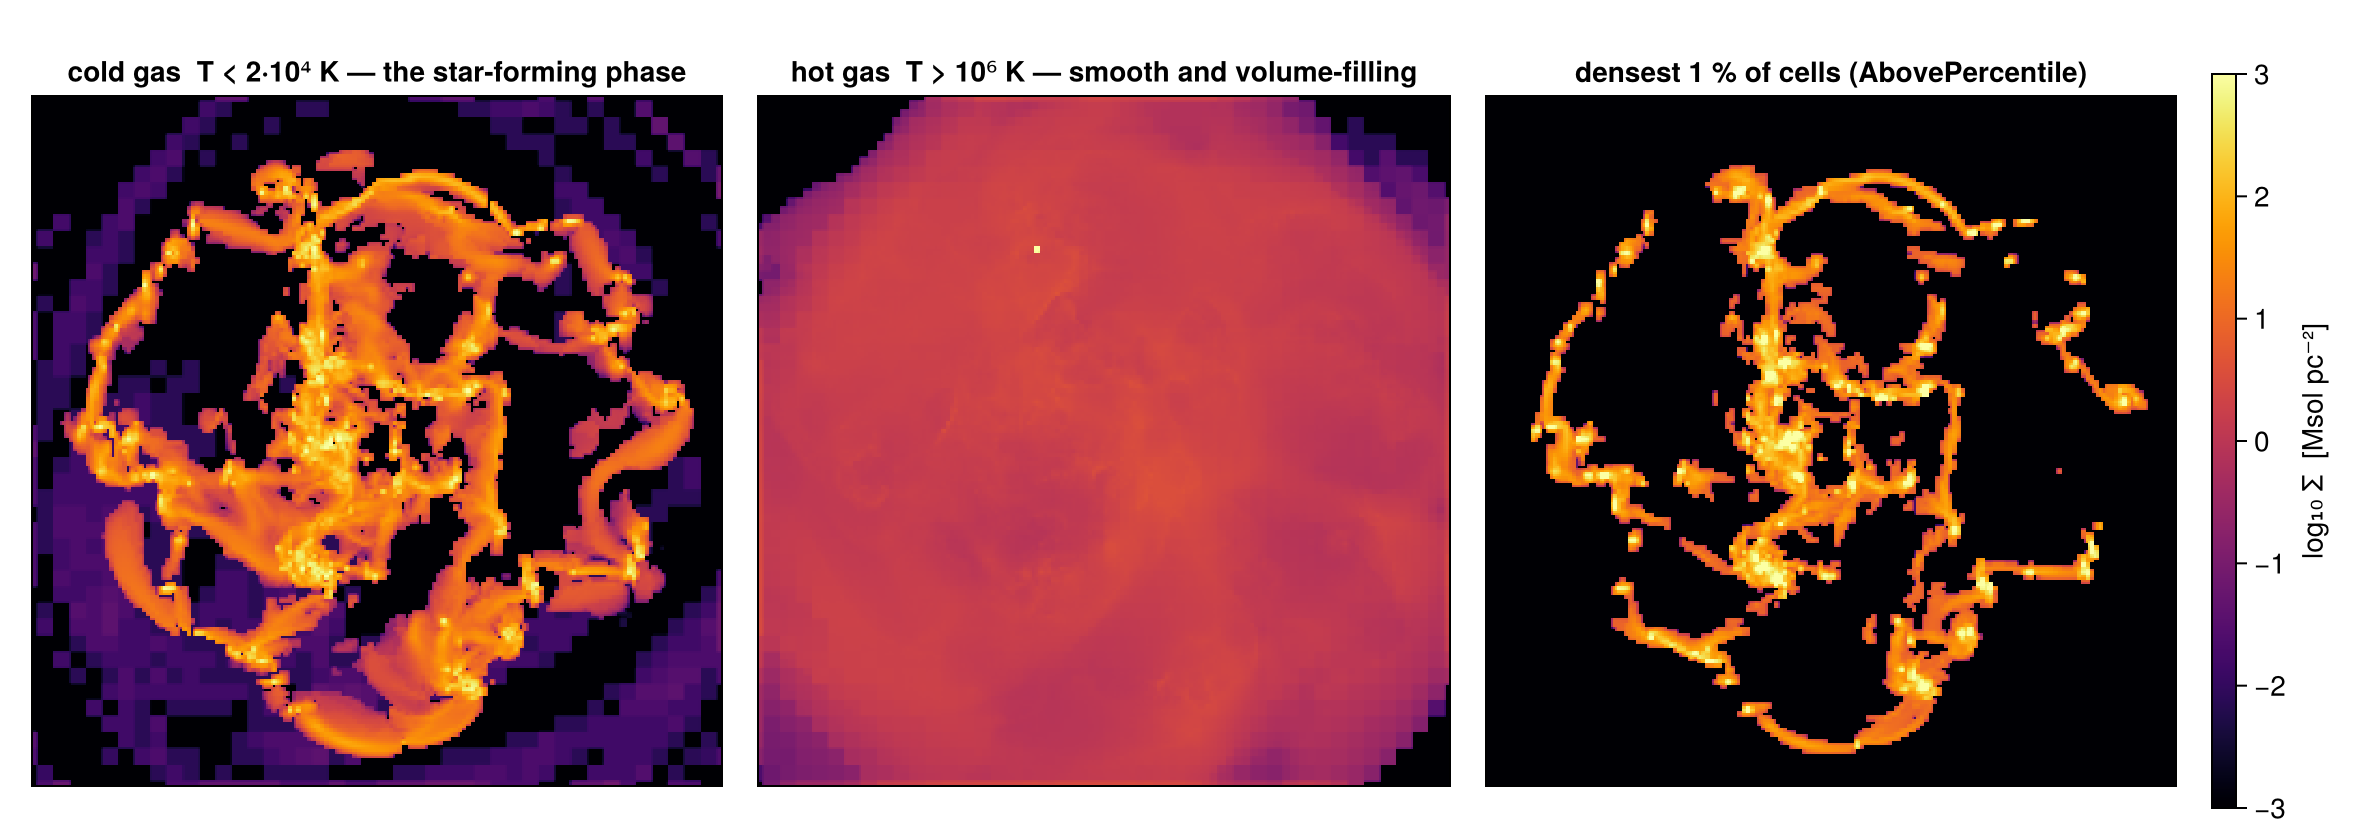

In [9]:
cold_g = filterdata(gas, Below(:T, 2e4, unit=:K), verbose=false)     # state only — full box
hot_g  = filterdata(gas, Above(:T, 1e6, unit=:K), verbose=false)
dense1 = filterdata(gas, AbovePercentile(:rho, 99), verbose=false)   # adaptive: densest 1 %

for (n, o) in (("cold  T<2e4 K ", cold_g), ("hot   T>1e6 K ", hot_g), ("densest 1%    ", dense1))
    println(n, ": ", rpad(length(o.data), 9), round(msum(o, :Msol), sigdigits=4),
            " Msol  = ", round(100*msum(o, :Msol)/m_all, digits=1), " % of the box")
end


# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
fig = Figure(size=(1180, 420))
sdpanel!(Axis(fig[1, 1], title="cold gas  T < 2·10⁴ K — the star-forming phase"), prj(cold_g))
sdpanel!(Axis(fig[1, 2], title="hot gas  T > 10⁶ K — smooth and volume-filling"), prj(hot_g))
sdpanel!(Axis(fig[1, 3], title="densest 1 % of cells (AbovePercentile)"), prj(dense1))
Colorbar(fig[1, 4]; colormap=:inferno, colorrange=SDLIM5, label="log₁₀ Σ  [Msol pc⁻²]")
fig


Three views of one simulation, on one colour scale. The cold phase is
filamentary and carries 37 % of the mass in 4 % of the cells; the hot phase is
smooth and volume-filling, 6.9 % of the mass spread over most of the box; and the
densest percentile — a *relative* threshold — isolates the clumps while holding
79 % of the mass, without anyone having to know this run's density scale.

Read the middle panel with the usual care: it is a column density, so a smooth
map means the hot gas is spread along every line of sight, not that it is
structureless in 3-D.


## 7. Place × Value

Geometry and state are independent, so they compose, and the order cannot change
the answer. Here the disc is cut as an **exact split region** (boundary cells
carry their `:fraction`) and then partitioned by temperature.


In [10]:
import Mera: Cylinder     # Mera's region type (plotting packages export a Cylinder too)

disc_reg = Cylinder(12., 2.; center=[:bc], range_unit=:kpc)   # radius, half-height [kpc]
disc = subregion(gas, disc_reg, verbose=false)                # split: rim cells carry :fraction

cold_d = filterdata(disc, Below(:T, 2e4, unit=:K), verbose=false)
rest_d = filterdata(disc, !Below(:T, 2e4, unit=:K), verbose=false)

m_c, m_r, m_d = msum(cold_d, :Msol), msum(rest_d, :Msol), msum(disc, :Msol)
println("cold (< 2e4 K) in the disc : ", round(m_c, sigdigits=5), " Msol")
println("rest (≥ 2e4 K) in the disc : ", round(m_r, sigdigits=5), " Msol")
println("cold + rest  vs  disc      : ", round(m_c + m_r, sigdigits=9), "  vs  ",
        round(m_d, sigdigits=9), " Msol")
println()
# the other order gives the same rows
other = subregion(filterdata(gas, Below(:T, 2e4, unit=:K), verbose=false), disc_reg, verbose=false)
println("filter→region == region→filter cells : ", length(other.data) == length(cold_d.data))


cold (< 2e4 K) in the disc : 8.9066e9

 Msol
rest (≥ 2e4 K) in the disc : 1.3963e10 Msol
cold + rest  vs  disc      : 2.28691723e10  vs  2.28691723e10 Msol

filter→region == region→filter cells : true


The partition still closes exactly *inside a split region* — `filterdata`
preserves the `:fraction` column, so a half-inside boundary cell contributes its
half to whichever phase it belongs to. That is the property that lets you mix the
two selection styles without quietly losing mass at the rim.

The two edges in the map below are worth telling apart: the **outer rim** is
geometric and smooth, feathered by the fraction weighting; the **internal edges**
between cold and warm gas are value edges, and they are cell-sharp, because a
cell either passes the temperature test or does not — there is no such thing as
half a cell being cold.


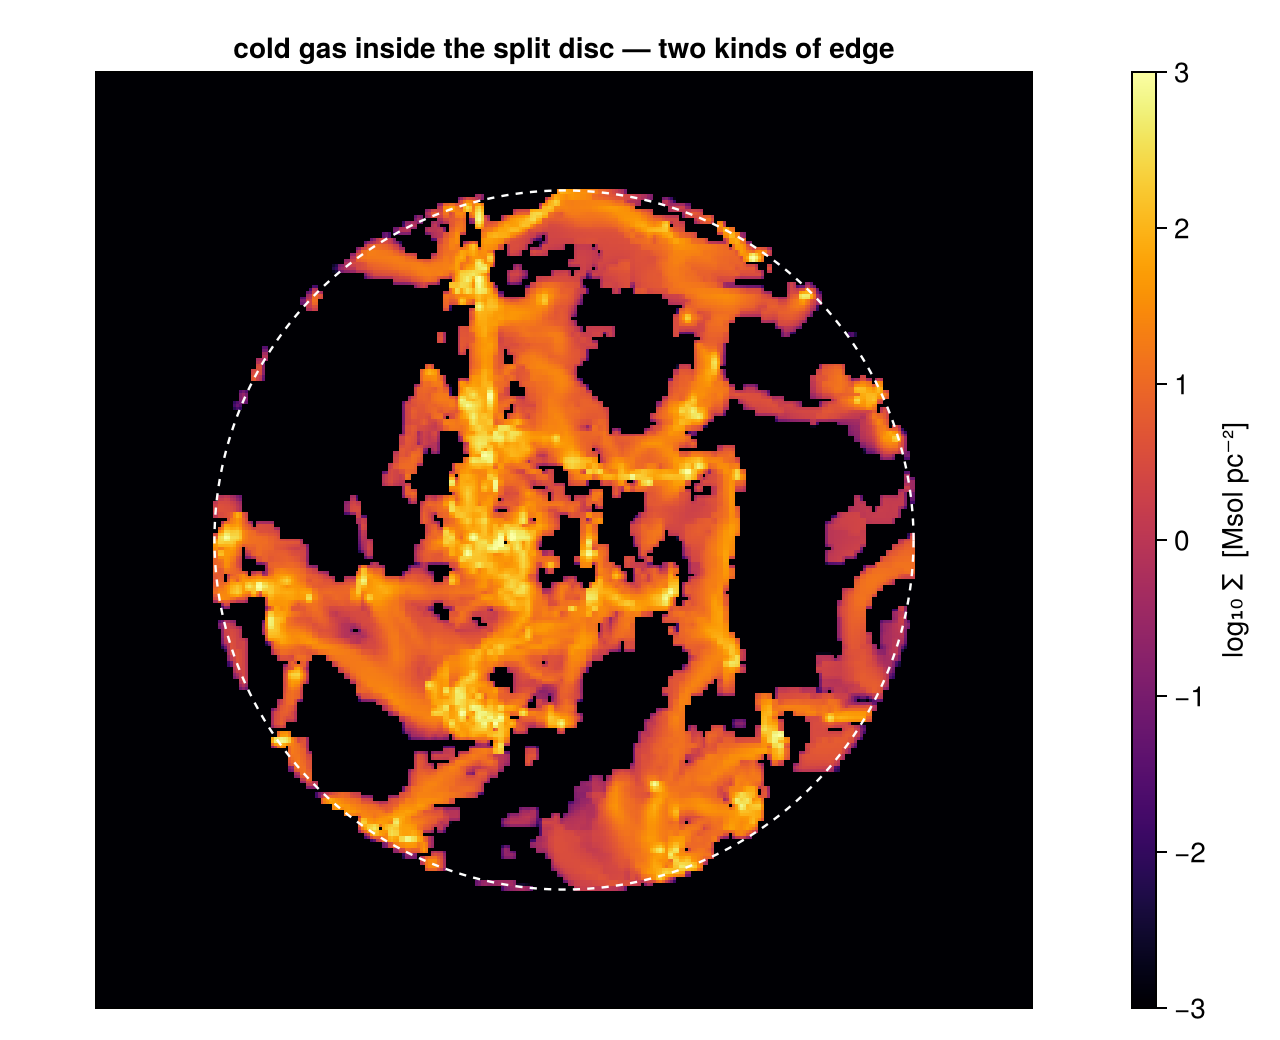

In [11]:
p_cd = prj(cold_d)


# ── figure code from here: panels, overlays, colorbars — no new Mera concepts ──
fig = Figure(size=(640, 520))
ax = Axis(fig[1, 1], title="cold gas inside the split disc — two kinds of edge")
sdpanel!(ax, p_cd)
arc!(ax, Point2f(0, 0), 12., 0, 2π; color=:white, linewidth=1.2, linestyle=:dash)
Colorbar(fig[1, 2]; colormap=:inferno, colorrange=SDLIM5, label="log₁₀ Σ  [Msol pc⁻²]")
fig


In [12]:
# match the geometric edge to the map's pixel size, so the rim is sharp where it is rendered
disc_px = subregion(gas, disc_reg; refine_to=[0.1, :kpc], verbose=false)
cold_px = filterdata(disc_px, Below(:T, 2e4, unit=:K), verbose=false)

fr = Mera.select(cold_px.data, :fraction)
cs = getvar(cold_px, :cellsize, :kpc)
println("largest straddling cell on the rim : ",
        round(maximum(cs[0.0 .< fr .< 1.0]), digits=3), " kpc   (map-ready)")
println("cold mass, refine_to vs plain      : ", round(msum(cold_px, :Msol) / m_c, digits=5))


largest straddling cell on the rim : 0.094

 kpc   (map-ready)
cold mass, refine_to vs plain      : 1.0


`refine_to` changes how sharply the boundary is *drawn*, not how much mass is
inside it — the ratio above is 1 to five digits. See §7 of the
[hydro sub-region page](03_hydro_Get_Subregions.md) for what it costs.


## 8. Adding a Column of Your Own

Any array as long as the table can be pushed in as a new column and then used
like a native one — projected, filtered, masked. `transform` adds it, `select …
Not(…)` removes it again.


In [13]:
using Mera.IndexedTables      # the table verbs (transform, select, Not, columns) live here

mach = getvar(gas, :mach)                       # a derived quantity, one value per cell
gas.data = transform(gas.data, :mach => mach)   # push it onto the table (IndexedTables)
println("columns now: ", propertynames(Mera.columns(gas.data)))

# it behaves like any other column from here on
supersonic = filterdata(gas, Above(:mach, 1), verbose=false)
println("supersonic cells : ", length(supersonic.data), "  = ",
        round(100*length(supersonic.data)/length(gas.data), digits=1), " % of the box")

gas.data = select(gas.data, Not(:mach))         # and take it away again
println("columns after removal: ", propertynames(Mera.columns(gas.data)))


columns now: (

:level, :cx, :cy, :cz, :rho, :vx, :vy, :vz, :p, :passive_scalar_1, :passive_scalar_2, :mach)
supersonic cells : 520858

  = 61.3 % of the box
columns after removal: (

:level, :cx, :cy, :cz, :rho, :vx, :vy, :vz, :p, :passive_scalar_1, :passive_scalar_2)


Mera already derives `:mach` on demand, so this is not the way to *get* a Mach
number — it is the way to attach something Mera cannot know about: a tracer, a
label from an external catalogue, the output of your own model.


## 9. Reference: the Raw Table Path

Underneath, a Mera object holds an `IndexedTable`, and every filter above can be
written directly against it. This is the older interface. It is still the right
tool when you need a predicate that is not a value condition — one that mixes
columns, or calls out to your own function — and it keeps existing scripts
working unchanged.

The trade-off: you work in **code units**, positions must be reconstructed by
hand, and the result is a *table*, not a Mera object.


In [14]:
# ---- reading columns: three equivalent ways -------------------------------------------
r1 = select(gas.data, :rho)                # IndexedTables
r2 = getvar(gas, :rho)                     # Mera (same array, and unit-aware on request)
vt = columns(gas.data, (:rho, :level))     # a NamedTuple of columns
println("select == getvar : ", r1 == r2, "   columns() gives ", propertynames(vt))

# ---- filtering rows: a predicate on the table ------------------------------------------
density = 3. / gas.scale.Msol_pc3          # threshold in CODE units — no unit= here
filtered_db = filter(p -> p.rho >= density, gas.data)
println("rows kept: ", length(filtered_db), " of ", length(gas.data))

# ---- using a filtered table ------------------------------------------------------------
#  (a) pass it to getvar via `filtered_db`
m_a = sum(getvar(gas, :mass, :Msol, filtered_db=filtered_db))
#  (b) or rebuild a full Mera object from it
gas_new = construct_datatype(filtered_db, gas)
m_b = sum(getvar(gas_new, :mass, :Msol))
#  (c) the value-space equivalent of the whole thing
m_c2 = msum(filterdata(gas, Above(:rho, 3, unit=:Msol_pc3), verbose=false), :Msol)
println("mass via filtered_db / construct_datatype / filterdata : ",
        round(m_a, sigdigits=8), "  ", round(m_b, sigdigits=8), "  ", round(m_c2, sigdigits=8))


select == getvar : true   columns() gives (:rho, :level)
rows kept: 210

 of 849332
mass via filtered_db / construct_datatype / filterdata : 1.4862768e10  1.4862768e10  1.4862768e10


In [15]:
# ---- multi-criteria on the raw table: geometry must be rebuilt by hand -----------------
boxlen = info.boxlen
cv     = boxlen / 2.                       # box centre, code units
radius = 3. / gas.scale.kpc
height = 2. / gas.scale.kpc

# a cell's CENTRE is (cx - 0.5) * boxlen / 2^level — cx is the 1-based index on the level grid
filtered_db = filter(p -> p.rho >= density &&
                     sqrt(((p.cx - 0.5) * boxlen/2^p.level - cv)^2 +
                          ((p.cy - 0.5) * boxlen/2^p.level - cv)^2) <= radius &&
                     abs((p.cz - 0.5) * boxlen/2^p.level - cv) <= height, gas.data)
println("hand-built cylinder + density : ", length(filtered_db), " rows, ",
        round(sum(getvar(gas, :mass, :Msol, filtered_db=filtered_db)), sigdigits=6), " Msol")

# the same thing as a region and a condition — units, exact boundary, and no geometry by hand
reg = Cylinder(3., 2.; center=[:bc], range_unit=:kpc)
sel = filterdata(subregion(gas, reg, verbose=false), Above(:rho, 3, unit=:Msol_pc3), verbose=false)
println("region × condition            : ", length(sel.data), " rows, ",
        round(msum(sel, :Msol), sigdigits=6), " Msol   (split boundary)")


hand-built cylinder + density : 33

 rows, 2.81234e9 Msol
region × condition            : 37 rows, 2.83126e9 Msol   (split boundary)


The two numbers differ, and the difference is the point of the sub-region pages:
the hand-built version keeps whole cells whose centres pass the test, the region
version weights the boundary cells by the fraction actually inside. Neither is
"wrong" — they answer slightly different questions — but only one of them adds up
when you put regions next to each other.

**Macros.** `@filter` writes a single comparison compactly, and — applied to a
Mera object rather than a table — routes through `filterdata`, so it returns an
object and understands derived quantities:


In [16]:
finest   = @filter gas :level == gas.lmax          # Mera object → HydroDataType
tbl_only = @filter gas.data :rho >= density        # raw table → IndexedTable
println("@filter on the object : ", typeof(finest).name.name, ", ", length(finest.data), " cells")
println("@filter on the table  : ", typeof(tbl_only).name.name, ", ", length(tbl_only), " rows")

# @apply chains several table-level conditions
filtered_db = @apply gas.data begin
    @where :rho >= density
    @where abs((:cz - 0.5) * boxlen/2^:level - cv) <= height
end
println("@apply pipeline       : ", length(filtered_db), " rows")


@filter on the object : HydroDataType

, 501568 cells
@filter on the table  : IndexedTable, 210 rows
@apply pipeline       : 210

 rows


In [17]:
# ---- hand-built masks, for comparison with getmask -------------------------------------
thr = 4. / gas.scale.Msol_pc3
mask_a = map(row -> row.rho < thr, gas.data)             # predicate over rows
mask_b = getvar(gas, :rho, :Msol_pc3) .< 4.              # broadcast over a getvar array
mask_c = getmask(gas, Below(:rho, 4, unit=:Msol_pc3))    # the value-space verb

println("all three agree : ", mask_a == mask_b == mask_c, "   (", count(mask_c), " cells)")
println("type            : ", typeof(mask_c))


all three agree : true

   (849177 cells)
type            : BitVector


All three produce the same `Vector{Bool}`. `getmask` is the one that states the
unit, works on derived quantities, and composes with `&` `|` `!` — the others are
worth knowing because they are what to reach for when the test is not expressible
as a condition on one quantity.


## 10. Practical Guidance

**Say the unit.** `Above(:rho, 1, unit=:nH)` is a statement about physics;
`p.rho >= 3.0` on the raw table is a statement about this run's code units and
will mean something different in the next simulation.

**Filter, then look.** A condition is cheap and a map is cheap. §6 takes seconds
and catches a threshold that selects nothing — or everything — before it becomes
a result.

**Check the partition.** A condition and its `!` must reproduce the parent's
count and mass. One line, and it catches an inverted comparison immediately.

**Choose the shape deliberately.** `filterdata` when the subset is the object of
study; `getmask` when you want a statistic of the whole restricted to a part, or
several subsets of one object without copying.

**Percentiles when the scale is unknown.** `AbovePercentile(:rho, 99)` ports
between simulations; `Above(:rho, 1e3, unit=:nH)` does not, unless you mean it
absolutely.

**Geometry belongs in a region.** `InRange(:r_cylinder, …)` works, but it is a
centre test with no boundary treatment. If the geometry matters, cut it as a
region (§7) and let the boundary cells carry their fractions.


## Summary

- Two verbs: `filterdata` returns an **object** you can carry on working with,
  `getmask` returns a **`Vector{Bool}`** for any Mera function that takes `mask=`.
  They select identically (§1, §4).
- A condition is a **quantity, a threshold and a unit**, and the quantity can be
  anything `getvar` derives — temperature, sound speed, Mach number, age (§2).
- Conditions compose with `&`, `|`, `!`; several arguments mean AND; and
  `AbovePercentile`/`BelowPercentile` set the threshold from the data itself
  (§3).
- Value selection and geometric selection are **independent and commute**, and
  `filterdata` preserves a split region's `:fraction`, so a mass budget still
  closes when you mix them (§7).
- The raw `IndexedTables` path is still there for predicates that are not value
  conditions — at the price of code units and hand-built geometry (§9).

**Continue with:**

- [Hydro sub-regions](03_hydro_Get_Subregions.md) — selection by place, exact
  cell splitting, and mass budgets.
- The sibling sub-region pages for
  [particles](03_particles_Get_Subregions.md),
  [gravity](03_gravity_Get_Subregions.md) and
  [clumps](03_clumps_Get_Subregions.md).
- [How Quantities Are Computed](computation_reference.md) — the formula behind
  every quantity a condition can name.
